In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [4]:

df.shape

(10000, 10)

In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [7]:
df.drop(columns=['UDI','Product ID'],inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  str    
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Target                   10000 non-null  int64  
 7   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(3), str(2)
memory usage: 625.1 KB


In [9]:
df['Target'].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [10]:
df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure


In [13]:
df['Air temperature [C]'] = df['Air temperature [K]'] - 273.15
df['Pocess temperature [C]'] = df['Process temperature [K]'] - 273.15

In [14]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Air temperature [C],Pocess temperature [C]
0,M,298.1,308.6,1551,42.8,0,0,No Failure,24.95,35.45
1,L,298.2,308.7,1408,46.3,3,0,No Failure,25.05,35.55
2,L,298.1,308.5,1498,49.4,5,0,No Failure,24.95,35.35
3,L,298.2,308.6,1433,39.5,7,0,No Failure,25.05,35.45
4,L,298.2,308.7,1408,40.0,9,0,No Failure,25.05,35.55


In [15]:
df.drop(['Air temperature [K]', 'Process temperature [K]'], axis =1, inplace=True)

In [16]:
df.head()

,Type,Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Air temperature [C],Pocess temperature [C]
0,M,1551,42.8,0,0,No Failure,24.95,35.45
1,L,1408,46.3,3,0,No Failure,25.05,35.55
2,L,1498,49.4,5,0,No Failure,24.95,35.35
3,L,1433,39.5,7,0,No Failure,25.05,35.45
4,L,1408,40.0,9,0,No Failure,25.05,35.55


In [17]:
df['Tool wear [min]'].value_counts()

Tool wear [min]
0      120
2       69
5       63
7       58
59      58
      ... 
237      1
239      1
241      1
251      1
253      1
Name: count, Length: 246, dtype: int64

# Exploratory Data Analysis

<Axes: xlabel='Type'>

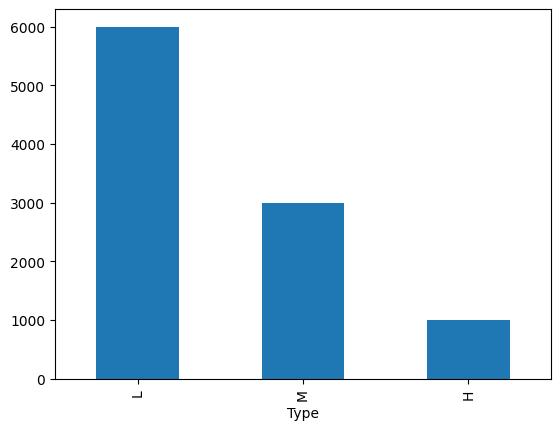

In [18]:
df['Type'].value_counts().plot(kind='bar')

<Axes: xlabel='Target'>

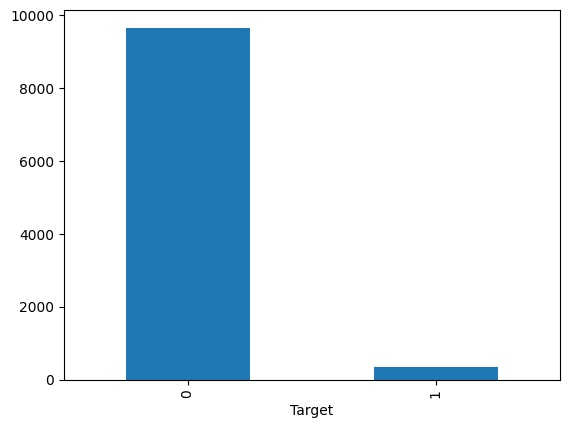

In [19]:
df['Target'].value_counts().plot(kind='bar')

<Axes: xlabel='Tool wear [min]'>

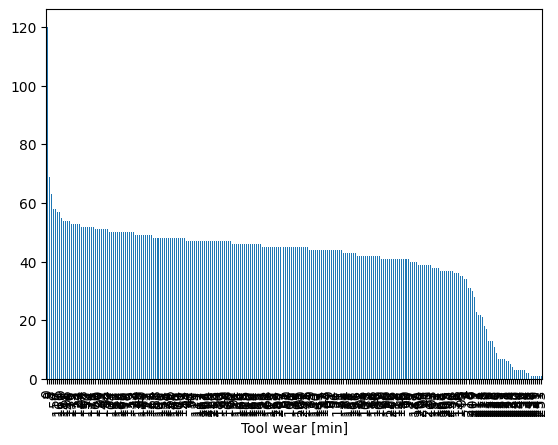

In [20]:
df['Tool wear [min]'].value_counts().plot(kind='bar')

<Axes: xlabel='Failure Type', ylabel='count'>

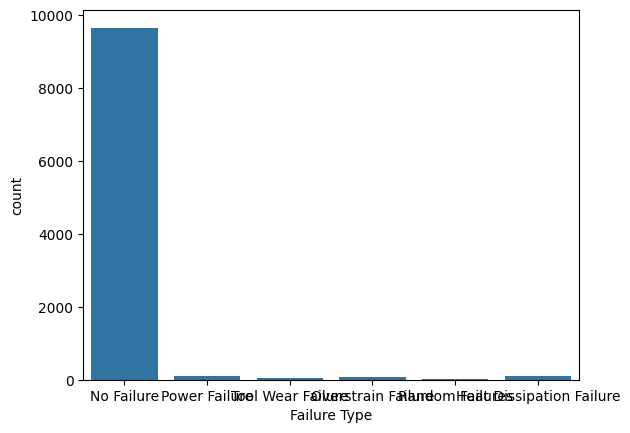

In [21]:
sns.countplot(x='Failure Type',data=df)

(array([ 153.,  400., 1394., 1620., 1246., 1792., 1179., 1203.,  552.,
         461.]),
 array([22.15, 23.07, 23.99, 24.91, 25.83, 26.75, 27.67, 28.59, 29.51,
        30.43, 31.35]),
 <BarContainer object of 10 artists>)

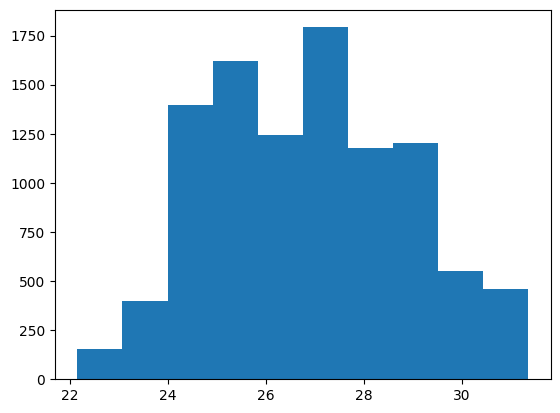

In [22]:
plt.hist(df['Air temperature [C]'])

(array([  98.,  123.,  843., 1655., 1692., 1724., 1944., 1141.,  528.,
         252.]),
 array([32.55, 33.36, 34.17, 34.98, 35.79, 36.6 , 37.41, 38.22, 39.03,
        39.84, 40.65]),
 <BarContainer object of 10 artists>)

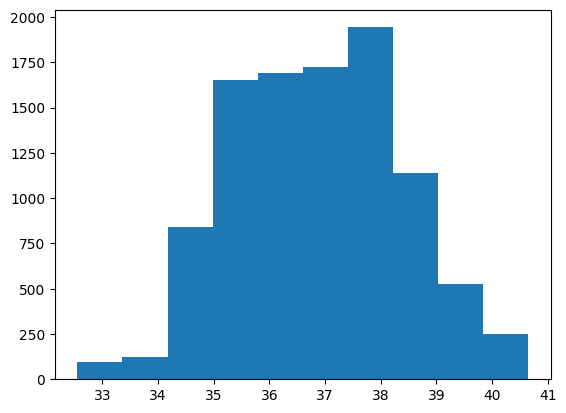

In [23]:
plt.hist(df['Pocess temperature [C]'])

In [24]:
df.head(1)

,Type,Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Air temperature [C],Pocess temperature [C]
0,M,1551,42.8,0,0,No Failure,24.95,35.45


In [25]:
df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

<Axes: xlabel='Failure Type', ylabel='Rotational speed [rpm]'>

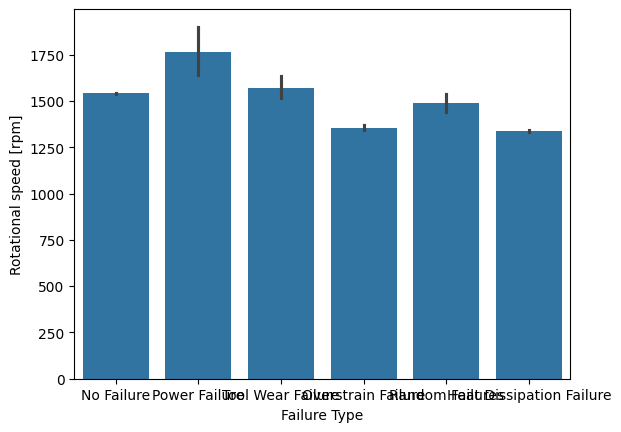

In [26]:
sns.barplot(x='Failure Type',y='Rotational speed [rpm]',data=df)

# Preprocessing 

In [27]:
# ordinal Encoding

from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['L','M','H']])
df['Type'] = oe.fit_transform(df[['Type']])

In [28]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Failure Type'] = le.fit_transform(df['Failure Type'])

In [29]:
df.head()

,Type,Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Air temperature [C],Pocess temperature [C]
0,1.0,1551,42.8,0,0,1,24.95,35.45
1,0.0,1408,46.3,3,0,1,25.05,35.55
2,0.0,1498,49.4,5,0,1,24.95,35.35
3,0.0,1433,39.5,7,0,1,25.05,35.45
4,0.0,1408,40.0,9,0,1,25.05,35.55


In [30]:
# Train test spplit

from sklearn.model_selection import train_test_split

X = df.drop(['Target', 'Failure Type'], axis=1)

y1 = df['Target']
y2 = df['Failure Type']

X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(X,y1,y2,test_size=0.2,random_state=42,stratify=y1)

In [31]:
print("X_train shape",X_train.shape)
print("X_test shape", X_test.shape)
print("y1_train distribution:\n", y1_train.value_counts())
print("y2_train distribution:\n", y2_train.value_counts())


X_train shape (8000, 6)
X_test shape (2000, 6)
y1_train distribution:
 Target
0    7729
1     271
Name: count, dtype: int64
y2_train distribution:
 Failure Type
1    7722
0      84
3      82
2      63
5      35
4      14
Name: count, dtype: int64


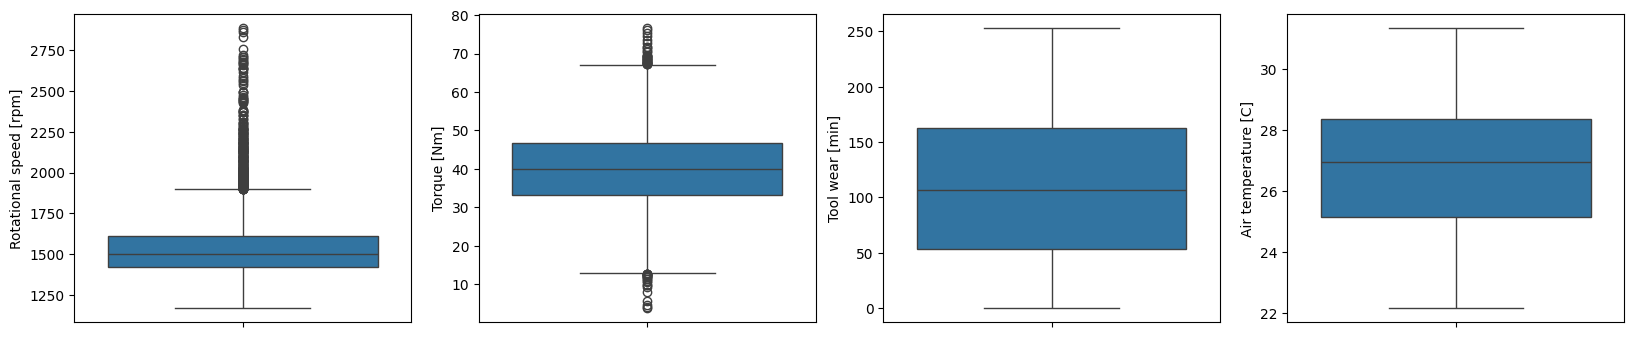

In [32]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
sns.boxplot(y=X_train['Rotational speed [rpm]'],ax=axes[0])
sns.boxplot(y=X_train['Torque [Nm]'],ax=axes[1])
sns.boxplot(y=X_train['Tool wear [min]'],ax=axes[2])
sns.boxplot(y=X_train['Air temperature [C]'],ax=axes[3])
plt.show()

In [33]:
X_train.head(1)

,Type,Rotational speed [rpm],Torque [Nm],Tool wear [min],Air temperature [C],Pocess temperature [C]
4058,1.0,1456,47.2,54,28.85,37.75


In [34]:
X_train

,Type,Rotational speed [rpm],Torque [Nm],Tool wear [min],Air temperature [C],Pocess temperature [C]
4058,1.0,1456,47.2,54,28.85,37.75
1221,1.0,1399,46.4,132,23.85,35.15
6895,1.0,1357,45.6,137,27.85,38.45
9863,0.0,1411,56.3,84,25.75,36.65
8711,0.0,1733,28.7,50,23.95,35.35
...,...,...,...,...,...,...
980,0.0,1409,42.8,134,22.95,33.55
4266,0.0,1440,39.5,146,29.55,37.95
7772,2.0,1464,41.0,29,27.15,38.35
5780,0.0,1517,42.4,113,28.55,38.05


In [35]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()

numerical_cols = ['Rotational speed [rpm]','Torque [Nm]','Tool wear [min]','Air temperature [C]', 'Pocess temperature [C]']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = rs.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = rs.transform(X_test[numerical_cols])

print(X_train_scaled.head())
print(X_train_scaled['Type'].unique())

      Type  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  \
4058   1.0               -0.246073     0.522059        -0.481818   
1221   1.0               -0.544503     0.463235         0.227273   
6895   1.0               -0.764398     0.404412         0.272727   
9863   0.0               -0.481675     1.191176        -0.209091   
8711   0.0                1.204188    -0.838235        -0.518182   

      Air temperature [C]  Pocess temperature [C]  
4058              0.59375                0.347826  
1221             -0.96875               -0.782609  
6895              0.28125                0.652174  
9863             -0.37500               -0.130435  
8711             -0.93750               -0.695652  
[1. 0. 2.]


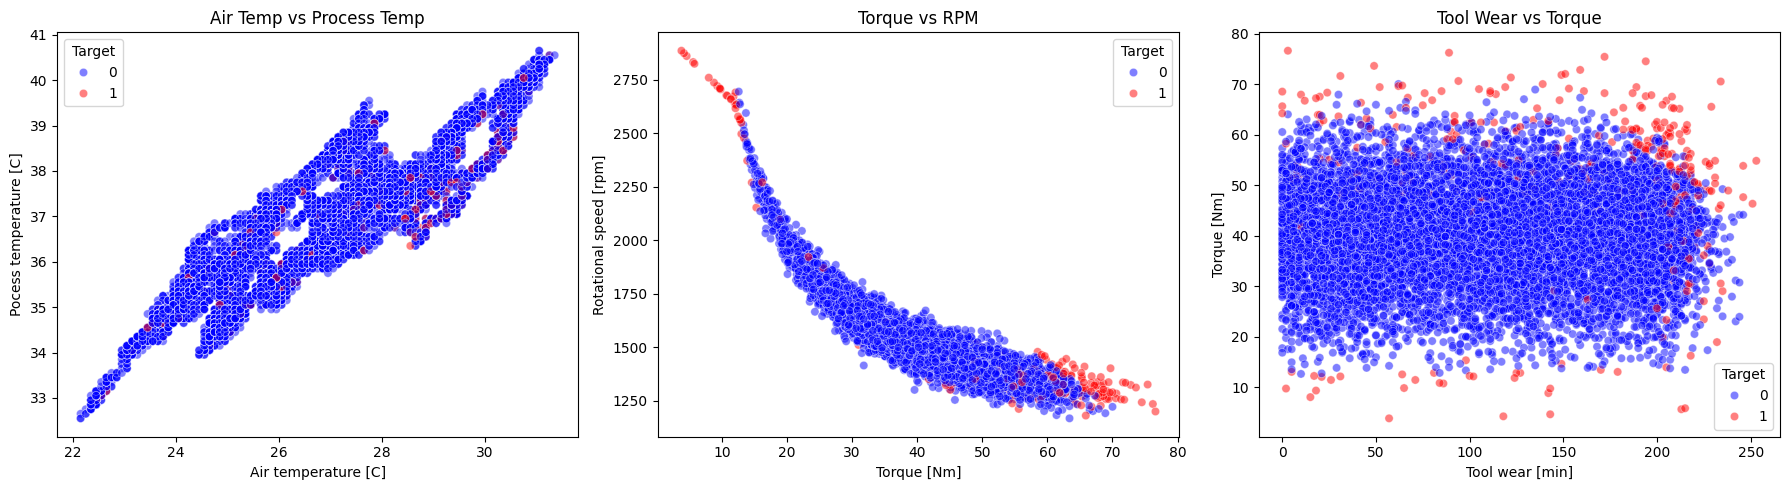

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=df, x='Air temperature [C]', y='Pocess temperature [C]', 
                 hue='Target', palette={0:'blue', 1:'red'}, alpha=0.5, ax=axes[0])
axes[0].set_title('Air Temp vs Process Temp')

sns.scatterplot(data=df, x='Torque [Nm]', y='Rotational speed [rpm]', 
                 hue='Target', palette={0:'blue', 1:'red'}, alpha=0.5, ax=axes[1])
axes[1].set_title('Torque vs RPM')

sns.scatterplot(data=df, x='Tool wear [min]', y='Torque [Nm]', 
                 hue='Target', palette={0:'blue', 1:'red'}, alpha=0.5, ax=axes[2])
axes[2].set_title('Tool Wear vs Torque')

plt.tight_layout()
plt.show()

<Axes: xlabel='Air temperature [C]', ylabel='Pocess temperature [C]'>

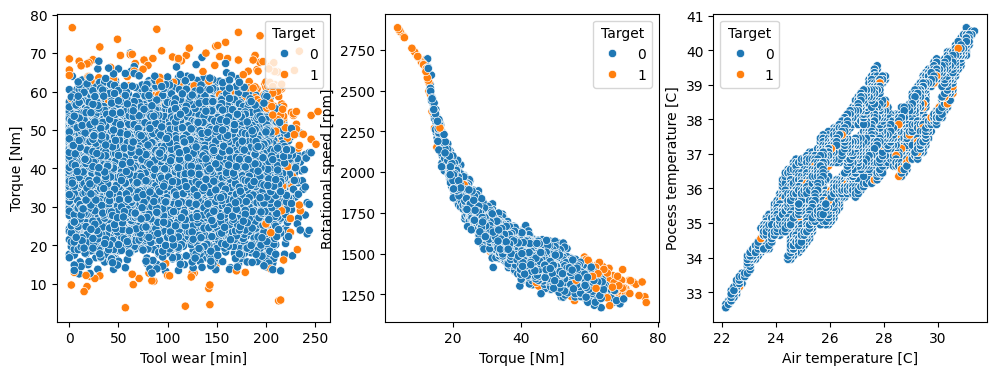

In [37]:
fig, axes = plt.subplots(1,3,figsize=(12,4))
sns.scatterplot(data=df, x='Tool wear [min]', y='Torque [Nm]', hue='Target',ax=axes[0])
sns.scatterplot(data=df,x='Torque [Nm]',y='Rotational speed [rpm]',hue='Target',ax=axes[1])
sns.scatterplot(data=df,x='Air temperature [C]',y='Pocess temperature [C]',hue='Target',ax=axes[2])

In [38]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


In [45]:
from sklearn.utils import resample

# Minority aur majority separate karo
train_data = pd.concat([X_train_scaled, y1_train.reset_index(drop=True)], axis=1)

majority = train_data[train_data['Target']==0]
minority = train_data[train_data['Target']==1]

# Minority ko upsample karo
minority_upsampled = resample(minority, 
                                replace=True,
                                n_samples=len(majority),
                                random_state=42)

train_balanced = pd.concat([majority, minority_upsampled])

X_train_balanced = train_balanced.drop('Target', axis=1)
y1_train_balanced = train_balanced['Target']

print(y1_train_balanced.value_counts())

Target
0.0    7729
1.0    7729
Name: count, dtype: int64


In [41]:
X_train

,Type,Rotational speed [rpm],Torque [Nm],Tool wear [min],Air temperature [C],Pocess temperature [C]
4058,1.0,1456,47.2,54,28.85,37.75
1221,1.0,1399,46.4,132,23.85,35.15
6895,1.0,1357,45.6,137,27.85,38.45
9863,0.0,1411,56.3,84,25.75,36.65
8711,0.0,1733,28.7,50,23.95,35.35
...,...,...,...,...,...,...
980,0.0,1409,42.8,134,22.95,33.55
4266,0.0,1440,39.5,146,29.55,37.95
7772,2.0,1464,41.0,29,27.15,38.35
5780,0.0,1517,42.4,113,28.55,38.05


<bound method DataFrame.nunique of        Type  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  \
0       1.0               -0.246073     0.522059        -0.481818   
1       1.0               -0.544503     0.463235         0.227273   
2       1.0               -0.764398     0.404412         0.272727   
3       1.0               -1.256545     0.897059        -0.027273   
4       2.0               -0.471204     0.007353        -0.509091   
...     ...                     ...          ...              ...   
15453   1.0                0.382199     0.022059        -0.136364   
15454   1.0                0.696335    -0.419118        -0.954545   
15455   NaN                     NaN          NaN              NaN   
15456   0.0               -0.083770     0.095588         0.409091   
15457   0.0                2.439791    -1.426471         0.018182   

       Air temperature [C]  Pocess temperature [C]  
0                  0.59375                0.347826  
1                 -0.96875    

In [63]:
import pandas as pd
from sklearn.utils import resample

# Step 1 — Fresh clean copy
X_train_scaled_clean = X_train_scaled.copy().reset_index(drop=True)
y1_train_clean = y1_train.reset_index(drop=True)

# Step 2 — Verify karo pehle
print("X shape:", X_train_scaled_clean.shape)
print("y shape:", y1_train_clean.shape)
print("X nulls:", X_train_scaled_clean.isnull().sum().sum())

# Step 3 — Combine X aur y
train_data = X_train_scaled_clean.copy()
train_data['Target'] = y1_train_clean.values  # .values use karo — index issue avoid hoga!

print("Combined nulls:", train_data.isnull().sum().sum())
print("Combined shape:", train_data.shape)

# Step 4 — Split majority/minority
majority = train_data[train_data['Target'] == 0]
minority = train_data[train_data['Target'] == 1]

print("\nMajority:", len(majority))
print("Minority:", len(minority))

# Step 5 — Upsample minority
minority_upsampled = resample(minority,
                               replace=True,
                               n_samples=len(majority),
                               random_state=42)

# Step 6 — Combine back
train_balanced = pd.concat([majority, minority_upsampled]).reset_index(drop=True)

# Step 7 — Split X aur y
X_train_balanced = train_balanced.drop('Target', axis=1).reset_index(drop=True)
y1_train_balanced = train_balanced['Target'].reset_index(drop=True)

# Step 8 — Final Verify
print("\n✅ Final Check:")
print("X_train_balanced shape:", X_train_balanced.shape)
print("Null values:", X_train_balanced.isnull().sum().sum())
print("Distribution:\n", y1_train_balanced.value_counts())

X shape: (8000, 6)
y shape: (8000,)
X nulls: 0
Combined nulls: 0
Combined shape: (8000, 7)

Majority: 7729
Minority: 271

✅ Final Check:
X_train_balanced shape: (15458, 6)
Null values: 0
Distribution:
 Target
0    7729
1    7729
Name: count, dtype: int64


In [64]:
X_train_balanced.isnull().sum()

Type                      0
Rotational speed [rpm]    0
Torque [Nm]               0
Tool wear [min]           0
Air temperature [C]       0
Pocess temperature [C]    0
dtype: int64

In [65]:
# Pehle ye kar rahe the — INDEX MISMATCH!
train_data['Target'] = y1_train_clean  

# Ab ye kar rahe hain — SAFE!
train_data['Target'] = y1_train_clean.values

In [62]:
y1_train_balanced.isnull().sum()

np.int64(0)

In [69]:
# Column names se special characters hata do
X_train_balanced.columns = X_train_balanced.columns.str.replace('[', '', regex=False)
X_train_balanced.columns = X_train_balanced.columns.str.replace(']', '', regex=False)
X_train_balanced.columns = X_train_balanced.columns.str.replace('<', '', regex=False)

X_test_scaled.columns = X_test_scaled.columns.str.replace('[', '', regex=False)
X_test_scaled.columns = X_test_scaled.columns.str.replace(']', '', regex=False)
X_test_scaled.columns = X_test_scaled.columns.str.replace('<', '', regex=False)

# Verify
print(X_train_balanced.columns.tolist())

['Type', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Air temperature C', 'Pocess temperature C']


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score,
                             classification_report)
import pandas as pd

# Reset Index
X_test_scaled = X_test_scaled.reset_index(drop=True)
y1_test = y1_test.reset_index(drop=True)

# Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train + Evaluate
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    model.fit(X_train_balanced, y1_train_balanced)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc       = accuracy_score(y1_test, y_pred)
    precision = precision_score(y1_test, y_pred)
    recall    = recall_score(y1_test, y_pred)
    f1        = f1_score(y1_test, y_pred)
    roc_auc   = roc_auc_score(y1_test, y_prob)
    
    results.append({
        'Model'    : name,
        'Accuracy' : round(acc, 4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1 Score' : round(f1, 4),
        'ROC AUC'  : round(roc_auc, 4)
    })
    
    print(classification_report(y1_test, y_pred, 
          target_names=['No Failure', 'Failure']))

# Comparison Table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False)
results_df = results_df.reset_index(drop=True)

print("\n" + "="*70)
print("FINAL COMPARISON TABLE")
print("="*70)
print(results_df.to_string(index=False))


Training: Logistic Regression
              precision    recall  f1-score   support

  No Failure       0.99      0.82      0.90      1932
     Failure       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000


Training: Decision Tree
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.69      0.60      0.65        68

    accuracy                           0.98      2000
   macro avg       0.84      0.80      0.82      2000
weighted avg       0.98      0.98      0.98      2000


Training: Random Forest
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.87      0.66      0.75        68

    accuracy                           0.98      2000
   macro avg       0.93      0.83      0.87    

In [73]:
import pandas as pd
from sklearn.utils import resample

# Step 1 — Fresh copy
X_train_scaled_clean = X_train_scaled.copy().reset_index(drop=True)
y2_train_clean = y2_train.reset_index(drop=True)

# Step 2 — Combine
train_data_mc = X_train_scaled_clean.copy()
train_data_mc['Failure Type'] = y2_train_clean.values

print("Before Oversampling:")
print(train_data_mc['Failure Type'].value_counts())

# Step 3 — Sabse badi class ka size
max_size = train_data_mc['Failure Type'].value_counts().max()
print(f"\nTarget size per class: {max_size}")

# Step 4 — Har class ko oversample karo
classes = train_data_mc['Failure Type'].unique()
oversampled_list = []

for cls in classes:
    class_data = train_data_mc[train_data_mc['Failure Type'] == cls]
    
    if len(class_data) < max_size:
        # Oversample karo
        class_upsampled = resample(class_data,
                                    replace=True,
                                    n_samples=max_size,
                                    random_state=42)
        oversampled_list.append(class_upsampled)
    else:
        oversampled_list.append(class_data)

# Step 5 — Combine all classes
train_balanced_mc = pd.concat(oversampled_list).reset_index(drop=True)

# Step 6 — Split X aur y
X_train_balanced_mc = train_balanced_mc.drop('Failure Type', axis=1).reset_index(drop=True)
y2_train_balanced = train_balanced_mc['Failure Type'].reset_index(drop=True)

# Step 7 — Verify
print("\nAfter Oversampling:")
print(y2_train_balanced.value_counts())
print("\nX shape:", X_train_balanced_mc.shape)
print("Null values:", X_train_balanced_mc.isnull().sum().sum())

Before Oversampling:
Failure Type
1    7722
0      84
3      82
2      63
5      35
4      14
Name: count, dtype: int64

Target size per class: 7722

After Oversampling:
Failure Type
1    7722
4    7722
0    7722
3    7722
2    7722
5    7722
Name: count, dtype: int64

X shape: (46332, 6)
Null values: 0


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report)
import pandas as pd

# Reset index
X_test_scaled_mc = X_test_scaled.reset_index(drop=True)
y2_test_clean = y2_test.reset_index(drop=True)

# Class names (Label Encoder ne jo order assign kiya tha)
class_names = ['Heat Dissipation', 'No Failure', 
               'Overstrain', 'Power Failure', 
               'Random Failures', 'Tool Wear']

# Models
models_mc = {
    'Logistic Regression': LogisticRegression(random_state=42, 
                                               max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, 
                                                   random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'XGBoost'            : XGBClassifier(random_state=42,
                                          eval_metric='mlogloss',
                                          num_class=6)
}

# Train + Evaluate
results_mc = []

for name, model in models_mc.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Train
    model.fit(X_train_balanced_mc, y2_train_balanced)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Metrics (weighted — class imbalance handle karta hai)
    acc       = accuracy_score(y2_test_clean, y_pred)
    precision = precision_score(y2_test_clean, y_pred, 
                                average='weighted', zero_division=0)
    recall    = recall_score(y2_test_clean, y_pred, 
                             average='weighted', zero_division=0)
    f1        = f1_score(y2_test_clean, y_pred, 
                         average='weighted', zero_division=0)
    
    results_mc.append({
        'Model'    : name,
        'Accuracy' : round(acc, 4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1 Score' : round(f1, 4),
    })
    
    # Detailed Report
    print(classification_report(y2_test_clean, y_pred,
                                 target_names=class_names,
                                 zero_division=0))

# Comparison Table
results_mc_df = pd.DataFrame(results_mc)
results_mc_df = results_mc_df.sort_values('F1 Score', ascending=False)
results_mc_df = results_mc_df.reset_index(drop=True)

print("\n" + "="*70)
print("FINAL COMPARISON TABLE — MULTI-CLASS")
print("="*70)
print(results_mc_df.to_string(index=False))


Training: Logistic Regression


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Air temperature C
- Pocess temperature C
- Rotational speed rpm
- Tool wear min
- Torque Nm
Feature names seen at fit time, yet now missing:
- Air temperature [C]
- Pocess temperature [C]
- Rotational speed [rpm]
- Tool wear [min]
- Torque [Nm]


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report)
import pandas as pd

# Reset index
X_test_scaled_mc = X_test_scaled.reset_index(drop=True)
y2_test_clean = y2_test.reset_index(drop=True)

# Class names (Label Encoder ne jo order assign kiya tha)
class_names = ['Heat Dissipation', 'No Failure', 
               'Overstrain', 'Power Failure', 
               'Random Failures', 'Tool Wear']

# Models
models_mc = {
    'Logistic Regression': LogisticRegression(random_state=42, 
                                               max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, 
                                                   random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'XGBoost'            : XGBClassifier(random_state=42,
                                          eval_metric='mlogloss',
                                          num_class=6)
}

# Train + Evaluate
results_mc = []

for name, model in models_mc.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Train
    model.fit(X_train_balanced_mc, y2_train_balanced)
    
    # Predict
    y_pred = model.predict(X_test_scaled_mc)
    
    # Metrics (weighted — class imbalance handle karta hai)
    acc       = accuracy_score(y2_test_clean, y_pred)
    precision = precision_score(y2_test_clean, y_pred, 
                                average='weighted', zero_division=0)
    recall    = recall_score(y2_test_clean, y_pred, 
                             average='weighted', zero_division=0)
    f1        = f1_score(y2_test_clean, y_pred, 
                         average='weighted', zero_division=0)
    
    results_mc.append({
        'Model'    : name,
        'Accuracy' : round(acc, 4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1 Score' : round(f1, 4),
    })
    
    # Detailed Report
    print(classification_report(y2_test_clean, y_pred,
                                 target_names=class_names,
                                 zero_division=0))

# Comparison Table
results_mc_df = pd.DataFrame(results_mc)
results_mc_df = results_mc_df.sort_values('F1 Score', ascending=False)
results_mc_df = results_mc_df.reset_index(drop=True)

print("\n" + "="*70)
print("FINAL COMPARISON TABLE — MULTI-CLASS")
print("="*70)
print(results_mc_df.to_string(index=False))


Training: Logistic Regression


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Air temperature C
- Pocess temperature C
- Rotational speed rpm
- Tool wear min
- Torque Nm
Feature names seen at fit time, yet now missing:
- Air temperature [C]
- Pocess temperature [C]
- Rotational speed [rpm]
- Tool wear [min]
- Torque [Nm]
